# BARPLOT


You have to check 3 things:

- The columns
- The Input
- The output

In [39]:
#Prepare data
import pandas as pd

#folder = "C:\\Users\\PEIXOTT\\LARGE_Map\\Phase1\\"
#psamTable = pd.read_table(f"{folder}\\merged_table.tsv")
folder = "C:\\Users\\PEIXOTT\\dataPlot\\DataToPlot_B1-10"
psamTable = pd.read_table(f"{folder}\\LARGE_Phase2_HWECase.psam")

psamTable.rename({'#IID': 'IID'}, axis=1, inplace=True)
psamTable['IID'] = psamTable['IID'].astype(str)


parentalDict = {}
ancList = ["AFR", "EUR", "EAS", "SAS", "AMR"]

for anc in ancList:
    listFile = open(f"C:\\Users\\PEIXOTT\\dataPlot\\Parentals\\{anc}.txt")
    for line in listFile:
        parentalDict[line.strip()] = {}
        parentalDict[line.strip()]["ANC"] = anc
        parentalDict[line.strip()]["POP"] = ""
    listFile.close()

popFile = open(f"C:\\Users\\PEIXOTT\\dataPlot\\Parentals\\ID_POP_1KGP_HGDP.txt")
for line in popFile:
    ID, POP = line.strip().split()
    POP = POP.split(",")[0]
    if ID in parentalDict:
        parentalDict[ID]["POP"] = POP
popFile.close()







In [59]:
#Prepare data
import pandas as pd

#folder = "C:\\Users\\PEIXOTT\\LARGE_Map\\Phase1\\"
#psamTable = pd.read_table(f"{folder}\\merged_table.tsv")
folder = "C:\\Users\\PEIXOTT\\dataPlot\\DataToPlot_B1-10"
psamTable = pd.read_table(f"{folder}\\LARGE_Phase2_HWECase.psam")
psamTable.rename({'#IID': 'IID'}, axis=1, inplace=True)
psamTable['IID'] = psamTable['IID'].astype(str)
    
parentalDict = {}
ancList = ["AFR", "EUR", "EAS", "SAS", "AMR"]

for anc in ancList:
    listFile = open(f"C:\\Users\\PEIXOTT\\dataPlot\\Parentals\\{anc}.txt")
    for line in listFile:
        parentalDict[line.strip()] = {}
        parentalDict[line.strip()]["ANC"] = anc
        parentalDict[line.strip()]["POP"] = ""
    listFile.close()

popFile = open(f"C:\\Users\\PEIXOTT\\dataPlot\\Parentals\\ID_POP_1KGP_HGDP.txt")
for line in popFile:
    ID, POP = line.strip().split()
    POP = POP.split(",")[0]
    if ID in parentalDict:
        parentalDict[ID]["POP"] = POP
popFile.close()



for B in [1,2,3,4,5,6,7,8,910]:
    #Get sample per file
    fileFam = open(f"{folder}\\PerBatch\\B{B}.fam")
    sampleList = []
    for line in fileFam:
        sampleList.append(line.strip().split()[1])
    fileFam.close()
    
    print(f"Open: {folder}\\PerBatch\\B{B}.Q")
    Qfile = open(f"{folder}\\PerBatch\\B{B}.Q")
    newQ = open(f"{folder}\\PerBatch\\B{B}_withInfo.Q", "w")
    newQ.write("IND POP ANC Cluster0 Cluster1 Cluster2 Cluster3 Cluster4\n")
    count = 0
    for line in Qfile:
        sample = sampleList[count]
        
        if sample not in parentalDict:
            ANC = "LPD"
            POP = "ALL"
            if POP == "UCH":
                POP = "ALL"
            elif POP == "RE":
                if "X" in POP:
                    print (POP)
                POP = "ALL"
            newQ.write(f"{sample} {POP} LPD {line}")
        
        else:
            ANC = parentalDict[sample]["ANC"]
            POP = parentalDict[sample]["POP"]
            if ANC not in fileDict:
                fileDict[ANC] = ""
            newQ.write(f"{sample} {POP} {ANC} {line}")
      
    
        count = count + 1
    Qfile.close()

#Rename Headers to merge

alLDF = pd.DataFrame(columns=["IND","POP","ANC","AFR","EAS","EUR","NAT", "SAS"])
DFList = []

dictColor = {}
dictColor["AFR"] = "#1874CD"
dictColor["EUR"] = "#EE2C2C"
dictColor["EAS"] = "#FFD39B"
dictColor["SAS"] = "#E066FF"
dictColor["NAT"] = "#008B45"

print(f"Building the header")
for B in [1,2,3,4,5,6,7,8,910]:      
    print(f"\tB{B}")

    renameDict={}
    for parental in ["AFR","EAS","EUR","NAT", "SAS"]:
        renameDict["parental"] = 0
    
    
    df = pd.read_csv(f"{folder}\\PerBatch\\B{B}_withInfo.Q", sep = " ", header = 0)
    
    for parental in dictColor:
        parentalQuery = parental
        if parental == "NAT":
            parentalQuery = "AMR"
        parentalDF = df.query(f"ANC == '{parentalQuery}'")
    
        for col in parentalDF:
            if "Cluster" in col:
                if parentalDF[col].mean()>0.9:
                    #print(f"Col {col} is {parental}")
                    renameDict[col] = parental
    
    
    targetDF= df.rename(columns=renameDict).drop_duplicates()
    targetDF.to_csv(f"{folder}\\PerBatch\\TOQC_B{B}.csv", index = False, sep = " ")
    targetDF = targetDF.query(f"ANC == 'LPD'")
    DFList.append(targetDF)
    
df_combined = pd.concat(DFList, axis=0).to_csv(f"{folder}\\PerBatch\\MERGED_NoParental.tsv", index = False, sep = " ")

    
    


Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B1.Q
Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B2.Q
Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B3.Q
Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B4.Q
Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B5.Q
Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B6.Q
Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B7.Q
Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B8.Q
Open: C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\B910.Q
Building the header
	B1
	B2
	B3
	B4
	B5
	B6
	B7
	B8
	B910


In [52]:
#output all split by cases and control

fileDict = {}
fileDictPop = {}

print(f"Open {folder}\\PerBatch\\MERGED_NoParental.tsv")
Qfile = open(f"{folder}\\PerBatch\\MERGED_NoParental.tsv")
count = 0
header = True
for line in Qfile:
    sample = line.split()[0]
    if header:
        header = False
    else:
        if sample not in parentalDict:
            ANC = "LPD"
            POP = "ALL"
            if POP == "UCH":
                POP = "ALL"
            elif POP == "RE":
                if "X" in POP:
                    print (POP)
                POP = "ALL"
    
            status = str(psamTable.set_index("IID").loc[f"{sample}", "STATUS"]).replace("2", "P").replace("1", "C")
                  
            
            fileID = f"{POP}{status}" 
            if fileID not in fileDict:
                fileDict[fileID] = ""
            fileDict[fileID] = fileDict[fileID]+f"{line}"
            #fileDict[fileID] = fileDict[fileID]+f"{sample} {POP} LPD {line}"
        
        #else: Not needed anymore
            
            #ANC = parentalDict[sample]["ANC"]
            #POP = parentalDict[sample]["POP"]
            #if ANC not in fileDict:
            #    fileDict[ANC] = ""
            #fileDict[ANC] = fileDict[ANC]+f"{sample} {POP} {ANC} {line}"
  

    count = count + 1
Qfile.close()

for ID in fileDict:
    print(f"- {ID}")
    if ID not in ancList:
        fileOut = open(f"{folder}\\PerBatch\\{ID}.tsv", "w")
        fileOut.write("IND POP ANC EUR EAS NAT AFR SAS\n")
        #for anc in ancList:
        #    fileOut.write(fileDict[anc])
        fileOut.write(fileDict[ID])
        fileOut.close()    

Open C:\Users\PEIXOTT\dataPlot\DataToPlot_B1-10\PerBatch\MERGED_NoParental.csv
- ALLP
- ALLC


In [53]:
fileIn = open("C:\\Users\\PEIXOTT\\dataPlot\\DataToPlot_B1-10\\LARGE_Phase2_HWECase.psam")

dictData = {}
popList = []
header = True
for line in fileIn:
    if header:
        header = False
    else:
        IID, SEX, AGE, B, STATUS, POP = line.strip().split()
        dictData[IID] = {}
        dictData[IID]["SEX"] = SEX.replace("1","M").replace("2","F")
        dictData[IID]["POP"] = POP
        if POP not in popList:
            popList.append(POP)
        dictData[IID]["STATUS"] = STATUS.replace("1","C").replace("2","P")

dictOut = {}
for pop in popList:
    for status in ["P", "C"]:
        dictOut[f"{pop}_{status}"] = open(f"{folder}\\PerBatch\\Processed\\{pop}_{status}.tsv", "w")
        dictOut[f"{pop}_{status}"].write("IND POP ANC EUR EAS NAT AFR SAS\n")
    for sex in ["M", "F"]:
        dictOut[f"{pop}_{sex}"] = open(f"{folder}\\PerBatch\\Processed\\{pop}_{sex}.tsv", "w")
        dictOut[f"{pop}_{sex}"].write("IND POP ANC EUR EAS NAT AFR SAS\n")

fileQ = open(f"{folder}\\PerBatch\\ALLC.tsv")
header = True
ref =  ""
for line in fileQ:
    if header:
        header = False
    else:
        IND, POP, ANC, Cluster0, Cluster1, Cluster2, Cluster3, Cluster4 = line.strip().split()
        if ANC == "LPD":
            sex = dictData[IND]["SEX"]
            status = dictData[IND]["STATUS"]
            pop = dictData[IND]["POP"]

            dictOut[f"{pop}_{sex}"].write(line)
            dictOut[f"{pop}_{status}"].write(line)
        else:
            ref = f"{ref}{line}"


fileQ = open(f"{folder}\\PerBatch\\ALLP.tsv")
header = True
for line in fileQ:
    if header:
        header = False
    else:
        IND, POP, ANC, Cluster0, Cluster1, Cluster2, Cluster3, Cluster4 = line.strip().split()
        if ANC == "LPD":
            sex = dictData[IND]["SEX"]
            status = dictData[IND]["STATUS"]
            pop = dictData[IND]["POP"]

            dictOut[f"{pop}_{sex}"].write(line)
            dictOut[f"{pop}_{status}"].write(line)

for ID in dictOut:
    dictOut[ID].write(ref)
    dictOut[ID].close()
    


In [68]:
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt

import os

def isToPlot(file):
    popName = file.split("\\")[-1].replace(".tsv", "")
    if popName == "NUP":
        titlePlot = "FL"
        status = "P"
    elif popName == "XP":
        titlePlot = "CR"
        status = "P"
    elif popName == "XC":
        titlePlot = "CR"
        status = "C"
    else:
        if len(popName) < 3:
            titlePlot = popName[0:2]
            return popName, titlePlot, -1
            return -1, -1, -1
        titlePlot = popName[0:2]
        status = popName[2]
        #status = "P"
    
    return popName, titlePlot, status

def listBar(listFiles, outName):
    path = f"{folder}\\PerBatch\\Processed\\"
    count = 0
    
    sizePerSample = 100/924

    #Plot
    dfs = []
    widths = []
    popNames = []
    renameDict={}

    dictColor = {}
    dictColor["AFR"] = "#1874CD"
    dictColor["EUR"] = "#EE2C2C"
    dictColor["EAS"] = "#FFD39B"
    dictColor["SAS"] = "#E066FF"
    dictColor["NAT"] = "#008B45"

    #Getting all files in df
    for file in listFiles:
        popName = file.replace(".tsv", "").split("_")[0]
        print(f"Open file {file} ({popName})")
        

        #df = pd.read_csv(f"{path}/{file}", sep = " ", header = 0)

        #Made on the batch merge
        #Getting the column description
        #if not renameDict :
        #    
            
            
        #    for parental in dictColor:
        #        parentalQuery = parental
        #        if parental == "NAT":
        #            parentalQuery = "AMR"
        #        parentalDF = df.query(f"ANC == '{parentalQuery}'")
            
        #        for col in parentalDF:
        #            if "Cluster" in col:
        #                if parentalDF[col].mean()>0.9:
        #                    #print(f"Col {col} is {parental}")
        #                    renameDict[col] = parental

        
        #targetDF= df.rename(columns=renameDict).query(f"ANC == 'LPD'").drop_duplicates()
        #input(targetDF.head())
        targetDF = pd.read_csv(f"{path}/{file}", sep = " ", header = 0)
        if targetDF["IND"].empty:
            print(f"\tNo LPD samples in {file}")
        else:
            
            #Anc
            dictAnc = {}
            print("Mean per anc: ", end = "")
            for parental in dictColor:
                mean = targetDF[parental].mean()
                print(f" {parental}:{mean}", end = "")
                dictAnc[parental] = [mean]#Barplot
            print("")
            
            sortedDict = dict(sorted(dictAnc.items(), key=lambda x:x[1], reverse=True)) #Barplot
            
            desired = ['IND', 'POP', 'ANC']
            ordering = []
            for pop in sortedDict:
                desired.append(pop)
                ordering.append(pop)
                
            dfPlot = targetDF[desired]
            dfPlot = dfPlot.sort_values(ordering,ascending = False)
    
            #Saving on list
            dfs.append(dfPlot)
            popNames.append(f'{file.split("\\")[-1].replace(".tsv", "").split("_")[0]}')
            widths.append(dfPlot.shape[0] * sizePerSample*25)

    fig, axs = plt.subplots(1,len(dfs))
    
    scaling_factor = 0.1   # adjust as needed
    fig_width = sum(widths)
    fig_height = 5
    
    # Step 3: Create subplots with proportional widths
    fig, axes = plt.subplots(
        1, len(dfs),
        figsize=(fig_width, fig_height),
        gridspec_kw={'width_ratios': widths},
        constrained_layout=True
    )

    for ax, df, fname, width in zip(axes, dfs, popNames, widths):
        df.plot(kind='bar', ax=ax, stacked=True,  
                yticks=[],xticks=[],
                figsize=(width,10),
                width=1, 
                color=dictColor,
                ylim=(0,1),
                ylabel="", xlabel="",
                linewidth=0.0, legend = False)
        
        ax.set_title(f"{fname}")
        ax.margins(x=0)
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_visible(False)

    print("Plotted")
    plt.savefig(f"{outName}.svg", bbox_inches='tight')
    plt.cla()
    plt.clf()
    plt.close(fig)


Open file AR_F.tsv (AR)
Mean per anc:  AFR:0.012628027397260275 EUR:0.8498770136986301 EAS:1e-05 SAS:0.007296082191780823 NAT:0.1301889589041096
Open file BE_F.tsv (BE)
Mean per anc:  AFR:0.1836915125 EUR:0.49422825000000004 EAS:0.0005029375 SAS:0.0011855375 NAT:0.3203918875
Open file CA_F.tsv (CA)
Mean per anc:  AFR:0.038579999999999996 EUR:0.8998630909090909 EAS:1e-05 SAS:0.003603454545454546 NAT:0.05794336363636365
Open file CB_F.tsv (CB)
Mean per anc:  AFR:0.038434414285714286 EUR:0.5639927571428571 EAS:1.0000000000000003e-05 SAS:0.0009157714285714282 NAT:0.39664714285714286
Open file CC_F.tsv (CC)
Mean per anc:  AFR:0.13413496551724138 EUR:0.4705114344827586 EAS:0.0015977793103448277 SAS:0.00023978620689655184 NAT:0.3935160344827586
Open file CH_F.tsv (CH)
Mean per anc:  AFR:0.00797326582278481 EUR:0.5986693291139242 EAS:0.000833316455696203 SAS:0.0006627594936708857 NAT:0.39186134810126577
Open file CO_F.tsv (CO)
Mean per anc:  AFR:0.09772957352941176 EUR:0.600254794117647 EAS:1.

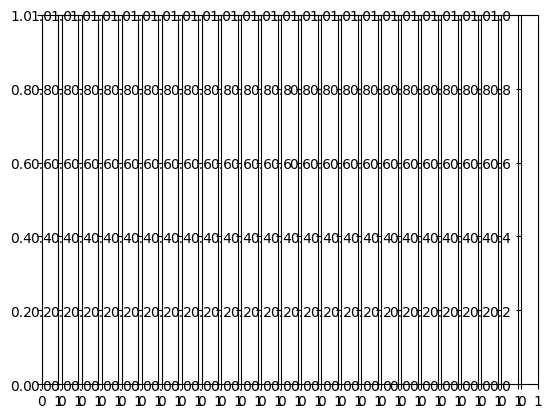

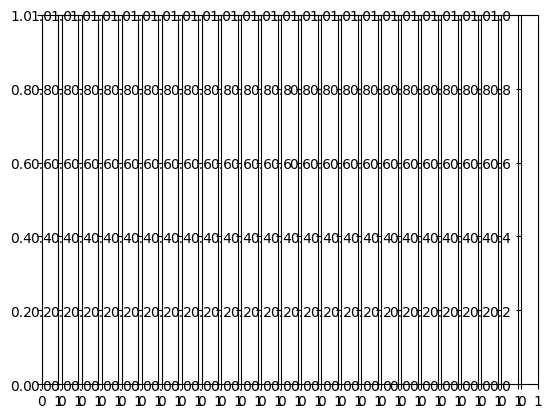

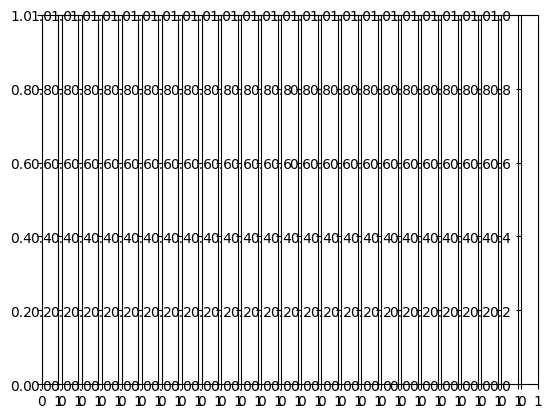

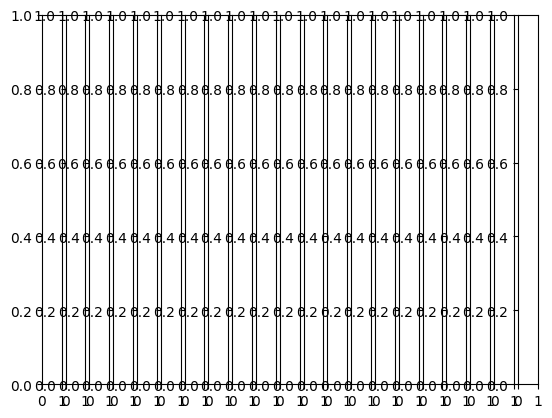

In [69]:
import os

path = f"{folder}\\PerBatch\\Processed\\"
fileList = os.listdir(path)

femalePlot = []
malePlot = []
patientPlot= []
controlPlot = []
for file in fileList:
    if file.endswith("_F.tsv"):
        femalePlot.append(file)
    elif file.endswith("_M.tsv"):
        malePlot.append(file)
    elif file.endswith("_P.tsv"):
        patientPlot.append(file)
    elif file.endswith("_C.tsv"):
        controlPlot.append(file)

listBar(femalePlot, f"FemalesMerged")
listBar(malePlot, f"MalesMerged")
listBar(patientPlot, f"PatientMerged")
listBar(controlPlot, f"ControlMerged")

In [64]:
plt.tight_layout()
plt.show() # Display the figure (optional)


<Figure size 640x480 with 0 Axes>

In [ ]:
path = f"C:\\Users\\PEIXOTT\\dataPlot\\DataToPlot_B1-10\\Processed\\"
fileList = os.listdir(path)
barAndPiePlot(f"{path}\\FL_C.tsv", "C:\\Users\\PEIXOTT\\dataPlot\\DataToPlot_B1-10\\Bar", "C:\\Users\\PEIXOTT\\dataPlot\\DataToPlot_B1-10\\Pie")
for file in fileList:
    barAndPiePlot(f"{path}\\{file}", "C:\\Users\\PEIXOTT\\dataPlot\\DataToPlot_B1-10\\Bar", "C:\\Users\\PEIXOTT\\dataPlot\\DataToPlot_B1-10\\Pie")

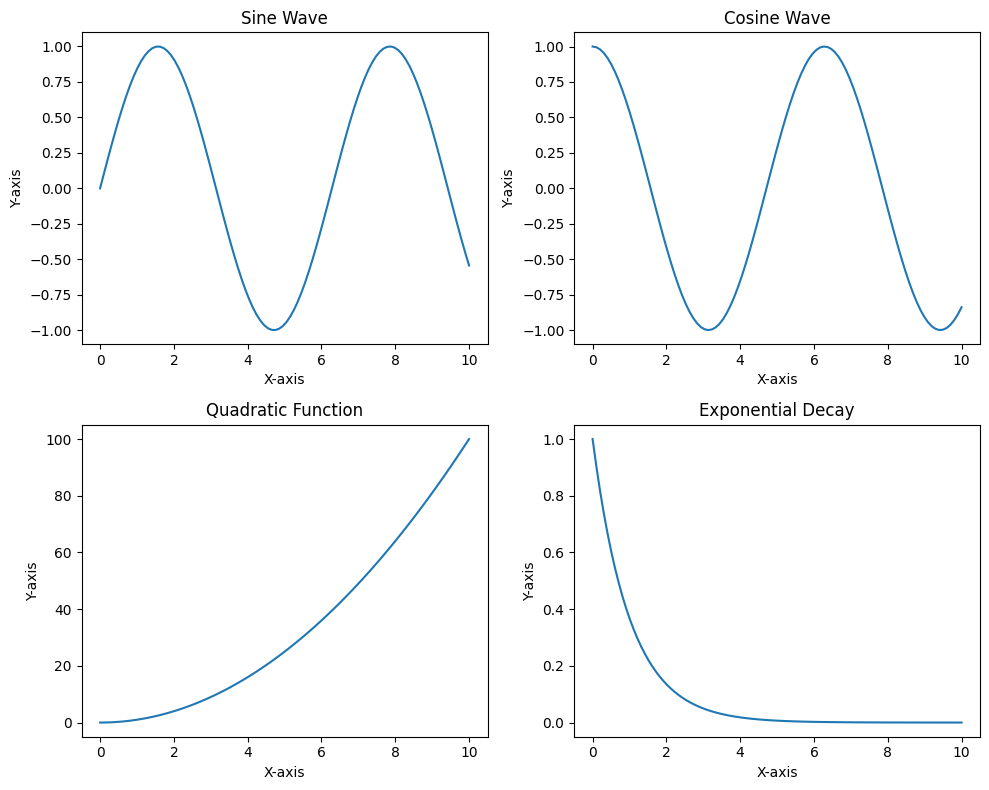

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Define a function that takes an Axes object and plots on it
def create_my_plot(ax, x_data, y_data, title):
    ax.plot(x_data, y_data)
    ax.set_title(title)
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# Generate some sample data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = x**2
y4 = np.exp(-x)

# Call the function for each subplot, passing the corresponding Axes object
create_my_plot(axes[0, 0], x, y1, "Sine Wave")
create_my_plot(axes[0, 1], x, y2, "Cosine Wave")
create_my_plot(axes[1, 0], x, y3, "Quadratic Function")
create_my_plot(axes[1, 1], x, y4, "Exponential Decay")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the figure with subplots
plt.show()